# Классификация резюме для HR

Этот ноутбук рассчитан на Google Colab и работает с датасетом резюме в CSV-формате.

Ожидаемые столбцы:
- `experience_text`
- `skills`
- `education`
- `total_experience`
- `last_position`
- `position` (не используется в признаках)
- `target`

Внутри есть:
- предобработка русского текста;
- TF-IDF;
- Logistic Regression;
- Random Forest;
- CatBoost;
- таблица метрик;
- ROC-кривые;
- матрицы ошибок;
- графики важности признаков.

In [1]:
!pip -q install catboost pymystem3 nltk scikit-learn pandas matplotlib

import os
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import TruncatedSVD

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from pymystem3 import Mystem
from catboost import CatBoostClassifier

RANDOM_STATE = 42
MAX_FEATURES = 5000
TEST_SIZE = 0.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [2]:
for resource in ["punkt", "stopwords"]:
    try:
        if resource == "punkt":
            nltk.data.find("tokenizers/punkt")
        else:
            nltk.data.find("corpora/stopwords")
    except LookupError:
        nltk.download(resource)

RU_STOPWORDS = set(stopwords.words("russian")) | {
    "кандидат", "резюме", "работа", "должность", "вакансия",
    "компания", "человек", "год", "месяц", "также", "очень",
    "опыт", "навык", "навыки", "умение", "умею", "работал",
    "работала", "работать", "проект", "проекты"
}

mystem = Mystem()

def safe_str(x):
    if pd.isna(x):
        return ""
    return str(x)

def preprocess_text(text: str) -> str:

    text = safe_str(text).lower()

    text = re.sub(r"[^a-zа-яё\\s]", " ", text)
    text = re.sub(r"\\s+", " ", text).strip()

    tokens = word_tokenize(text, language="russian")

    filtered = []

    for token in tokens:

        if len(token) < 3:
            continue

        if token in RU_STOPWORDS:
            continue

        lemma = mystem.lemmatize(token)[0].strip()

        if len(lemma) < 3:
            continue

        if lemma in RU_STOPWORDS:
            continue

        filtered.append(lemma)

    return " ".join(filtered)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
Installing mystem to /root/.local/bin/mystem from http://download.cdn.yandex.net/mystem/mystem-3.1-linux-64bit.tar.gz


## Загрузка CSV

In [3]:
uploaded = files.upload()

if not uploaded:
    raise RuntimeError("CSV-файл не загружен.")

DATA_PATH = next(iter(uploaded.keys()))
print("Загруженный файл:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
df.columns = [c.strip().lower() for c in df.columns]
print(df.head())
print("\nColumns:", list(df.columns))
print("\nShape:", df.shape)

Saving data.csv to data (1).csv
Загруженный файл: data (1).csv
           position                                    experience_text  \
0   Product Manager  commercial experience with prioritization and ...   
1  Python Developer  reaaady to learn new tools; automated tasks. h...   
2       QA Engineer  ready to learn new tools; worked on web apps. ...   
3      Data Analyst  practical experience with statistics and dashb...   
4    Data Scientist  hands-on experience with scikit-learn and xgbo...   

                                              skills  \
0  prioritization, jira, sql, stakeholders, a/b t...   
1  docker, git, django, content, fastapi, rest, m...   
2  jira, pytest, selenium, oop, bug tracking, aut...   
3  statistics, pandas, support, dashboard, ab tes...   
4  python, xgboost, sql, hr, matplotlib, pandas, ...   

                                        education  total_experience  \
0  bachelor software engineering; 2016 graduation                 8   
1     master 

In [4]:
required_cols = ["experience_text", "skills", "education", "target"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Отсутствуют обязательные столбцы: {missing}")

# Дополнительные столбцы могут присутствовать, но не обязательны для пайплайна
print("Распределение целевой переменной:")
display(df["target"].value_counts(dropna=False).sort_index())

Распределение целевой переменной:


,count
target,
0,8275
1,4225


In [5]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
import re
import pandas as pd
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from pymystem3 import Mystem

# загрузка ресурсов
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

# стоп-слова
RU_STOPWORDS = set(stopwords.words("russian")) | {
    "кандидат", "резюме", "работа", "должность", "вакансия",
    "компания", "человек", "год", "месяц", "также", "очень",
    "опыт", "навык", "навыки", "умение", "умею", "работал",
    "работала", "работать", "проект", "проекты"
}

# лемматизатор
mystem = Mystem()

# объединение текстовых столбцов
df["full_text"] = (
    df["experience_text"].fillna("").astype(str)
    + " "
    + df["skills"].fillna("").astype(str)
    + " "
    + df["education"].fillna("").astype(str)
)

def preprocess_text(text):

    text = str(text).lower()

    text = re.sub(r"[^a-zа-яё\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = word_tokenize(text, language="russian")

    lemmas = []

    for token in tokens:

        if len(token) < 3:
            continue

        if token in RU_STOPWORDS:
            continue

        lemma = mystem.lemmatize(token)[0].strip()

        if len(lemma) < 3:
            continue

        if lemma in RU_STOPWORDS:
            continue

        lemmas.append(lemma)

    return " ".join(lemmas)

# Создание столбца clean_text
df["clean_text"] = df["full_text"].apply(preprocess_text)

# удаление слишком коротких записей
df = df[df["clean_text"].str.len() >= 10].copy()

print("УСПЕШНО")
print(df[["clean_text", "target"]].head())
print(df.shape)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


УСПЕШНО
                                          clean_text  target
0  commercial experience with prioritization and ...       1
1  reaaady learn new tools automated tasks hands ...       0
2  ready learn new tools worked web apps years en...       0
3  practical experience with statistics and dashb...       0
4  hands experience with scikit learn and xgboost...       0
(12500, 9)


## Разведочный анализ данных: распределения и частота слов

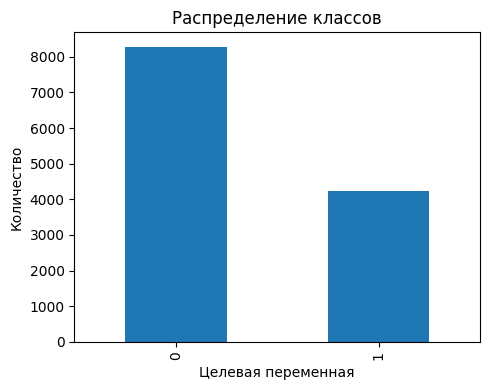

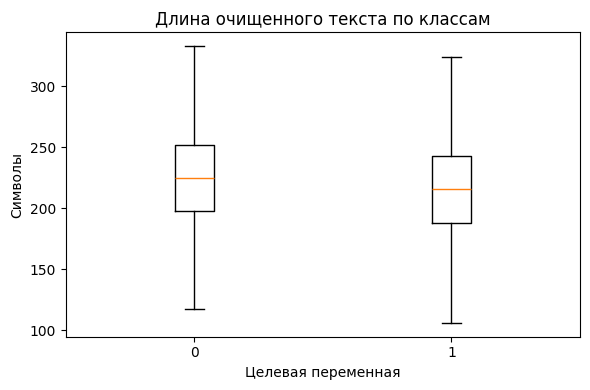

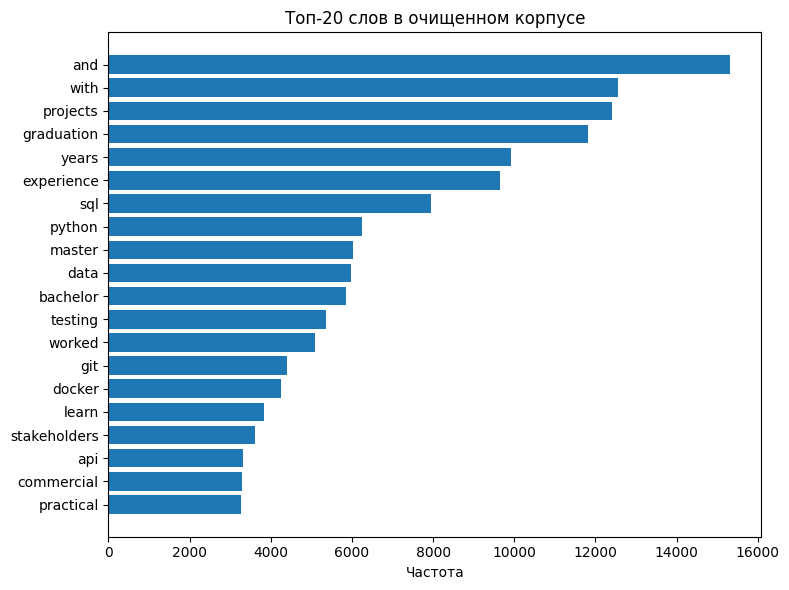

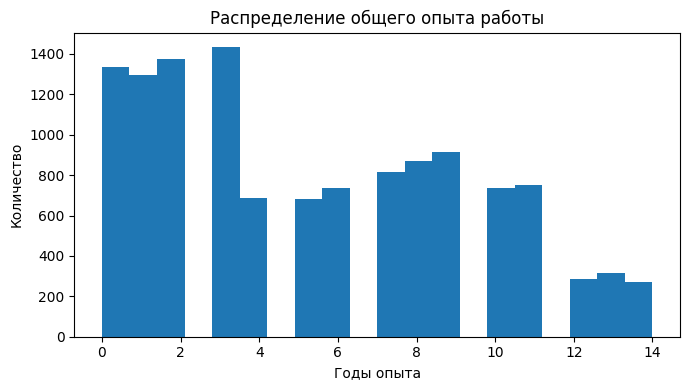

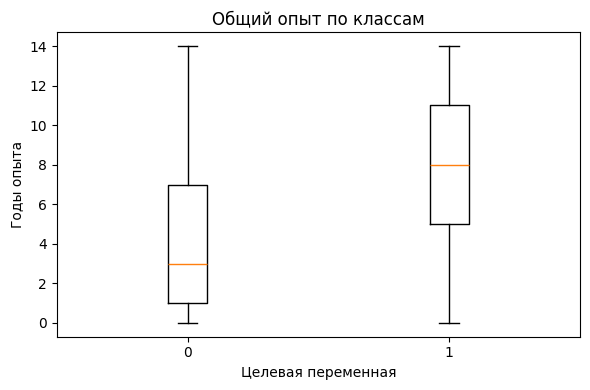

In [9]:
from collections import Counter

# Длина очищенного текста
df["text_len"] = df["clean_text"].fillna("").astype(str).str.len()

# 1) Распределение классов
plt.figure(figsize=(5, 4))
df["target"].value_counts().sort_index().plot(kind="bar")
plt.title("Распределение классов")
plt.xlabel("Целевая переменная")
plt.ylabel("Количество")
plt.tight_layout()
plt.show()

# 2) Диаграмма межквартильного размаха длины текста по классам
fig, ax = plt.subplots(figsize=(6, 4))
data_by_class = [
    df.loc[df["target"] == 0, "text_len"].dropna(),
    df.loc[df["target"] == 1, "text_len"].dropna(),
]
ax.boxplot(data_by_class, labels=["0", "1"], showfliers=False)
ax.set_title("Длина очищенного текста по классам")
ax.set_xlabel("Целевая переменная")
ax.set_ylabel("Символы")
plt.tight_layout()
plt.show()

# 3) Топ-20 слов в очищенном корпусе
tokens = " ".join(df["clean_text"].fillna("").astype(str)).split()
token_counts = Counter(tokens)
top_words = token_counts.most_common(20)

if top_words:
    words, counts = zip(*top_words)
    plt.figure(figsize=(8, 6))
    plt.barh(words[::-1], counts[::-1])
    plt.title("Топ-20 слов в очищенном корпусе")
    plt.xlabel("Частота")
    plt.tight_layout()
    plt.show()

# 4) Распределение опыта работы
if "total_experience" in df.columns:
    exp = pd.to_numeric(df["total_experience"], errors="coerce")
    exp = exp.dropna()

    plt.figure(figsize=(7, 4))
    plt.hist(exp, bins=20)
    plt.title("Распределение общего опыта работы")
    plt.xlabel("Годы опыта")
    plt.ylabel("Количество")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.boxplot([exp[df["target"] == 0], exp[df["target"] == 1]], labels=["0", "1"], showfliers=False)
    ax.set_title("Общий опыт по классам")
    ax.set_xlabel("Целевая переменная")
    ax.set_ylabel("Годы опыта")
    plt.tight_layout()
    plt.show()
else:
    print("Столбец 'total_experience' не найден, график опыта пропущен.")


In [10]:
X = df["clean_text"]
y = df["target"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Размер обучающей выборки:", X_train.shape[0])
print("Размер тестовой выборки:", X_test.shape[0])

Размер обучающей выборки: 10000
Размер тестовой выборки: 2500


In [11]:
tfidf = TfidfVectorizer(
    max_features=MAX_FEATURES,
    sublinear_tf=True,
    ngram_range=(1, 1),
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF‑IDF обучающая выборка:", X_train_tfidf.shape)
print("TF‑IDF тестовая выборка:", X_test_tfidf.shape)

TF‑IDF обучающая выборка: (10000, 3256)
TF‑IDF тестовая выборка: (2500, 3256)


In [12]:
log_reg = LogisticRegression(
    C=1.0,
    penalty="l2",
    solver="lbfgs",
    max_iter=1000,
    random_state=RANDOM_STATE,
)
log_reg.fit(X_train_tfidf, y_train)

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train_tfidf, y_train)

# CatBoost лучше работает с плотными признаками, поэтому используется SVD-снижение размерности
n_comp = min(100, X_train_tfidf.shape[1] - 1)

svd = TruncatedSVD(
    n_components=n_comp,
    random_state=RANDOM_STATE
)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    verbose=100,
    random_state=RANDOM_STATE,
    allow_writing_files=False,
)
cat.fit(X_train_svd, y_train, eval_set=(X_test_svd, y_test), use_best_model=True)

print("Модели успешно обучены.")

0:	learn: 0.6559125	test: 0.6560501	best: 0.6560501 (0)	total: 109ms	remaining: 54.4s
100:	learn: 0.3059837	test: 0.3425427	best: 0.3424054 (95)	total: 3.66s	remaining: 14.5s
200:	learn: 0.2691480	test: 0.3415147	best: 0.3411596 (140)	total: 8.99s	remaining: 13.4s
300:	learn: 0.2335504	test: 0.3425470	best: 0.3411147 (230)	total: 12.7s	remaining: 8.39s
400:	learn: 0.2056788	test: 0.3446305	best: 0.3411147 (230)	total: 16.1s	remaining: 3.98s
499:	learn: 0.1825815	test: 0.3448753	best: 0.3411147 (230)	total: 19.6s	remaining: 0us

bestTest = 0.3411146944
bestIteration = 230

Shrink model to first 231 iterations.
Модели успешно обучены.


In [13]:
def evaluate_model(name, y_true, y_pred, y_proba):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
    }

log_pred = log_reg.predict(X_test_tfidf)
log_proba = log_reg.predict_proba(X_test_tfidf)[:, 1]

rf_pred = rf.predict(X_test_tfidf)
rf_proba = rf.predict_proba(X_test_tfidf)[:, 1]

cat_pred = cat.predict(X_test_svd).astype(int)
cat_proba = cat.predict_proba(X_test_svd)[:, 1]

results = pd.DataFrame([
    evaluate_model("LogisticRegression", y_test, log_pred, log_proba),
    evaluate_model("RandomForest", y_test, rf_pred, rf_proba),
    evaluate_model("CatBoost", y_test, cat_pred, cat_proba),
]).sort_values("roc_auc", ascending=False)

display(results)

,model,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,0.8844,0.786598,0.902959,0.840771,0.895607
2,CatBoost,0.8768,0.777090,0.891124,0.830209,0.893252
1,RandomForest,0.6928,0.840708,0.112426,0.198330,0.885176


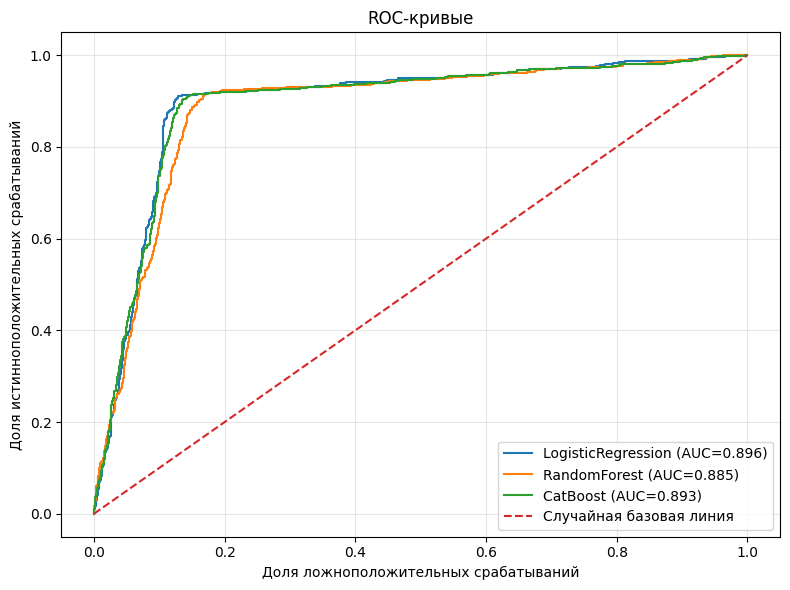

In [14]:
plt.figure(figsize=(8, 6))
for name, proba in {
    "LogisticRegression": log_proba,
    "RandomForest": rf_proba,
    "CatBoost": cat_proba,
}.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_value = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_value:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Случайная базовая линия")
plt.title("ROC-кривые")
plt.xlabel("Доля ложноположительных срабатываний")
plt.ylabel("Доля истинноположительных срабатываний")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

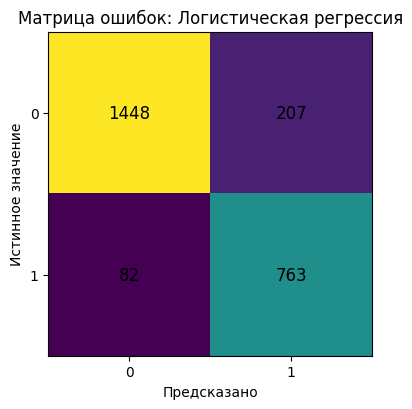

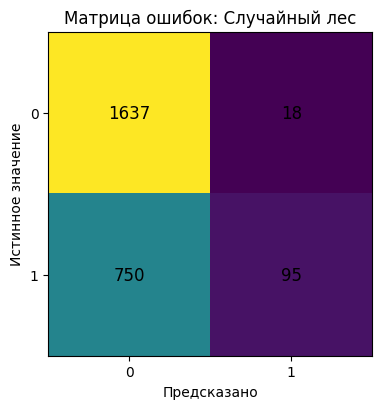

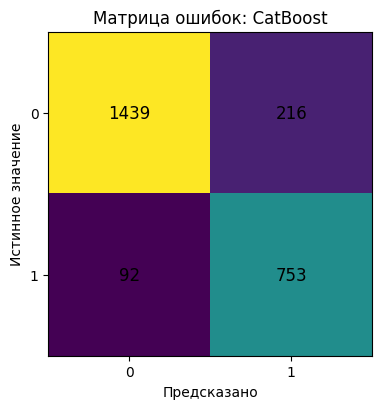

In [15]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Предсказано")
    ax.set_ylabel("Истинное значение")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=12)
    plt.tight_layout()
    plt.show()

plot_cm(y_test, log_pred, "Матрица ошибок: Логистическая регрессия")
plot_cm(y_test, rf_pred, "Матрица ошибок: Случайный лес")
plot_cm(y_test, cat_pred, "Матрица ошибок: CatBoost")

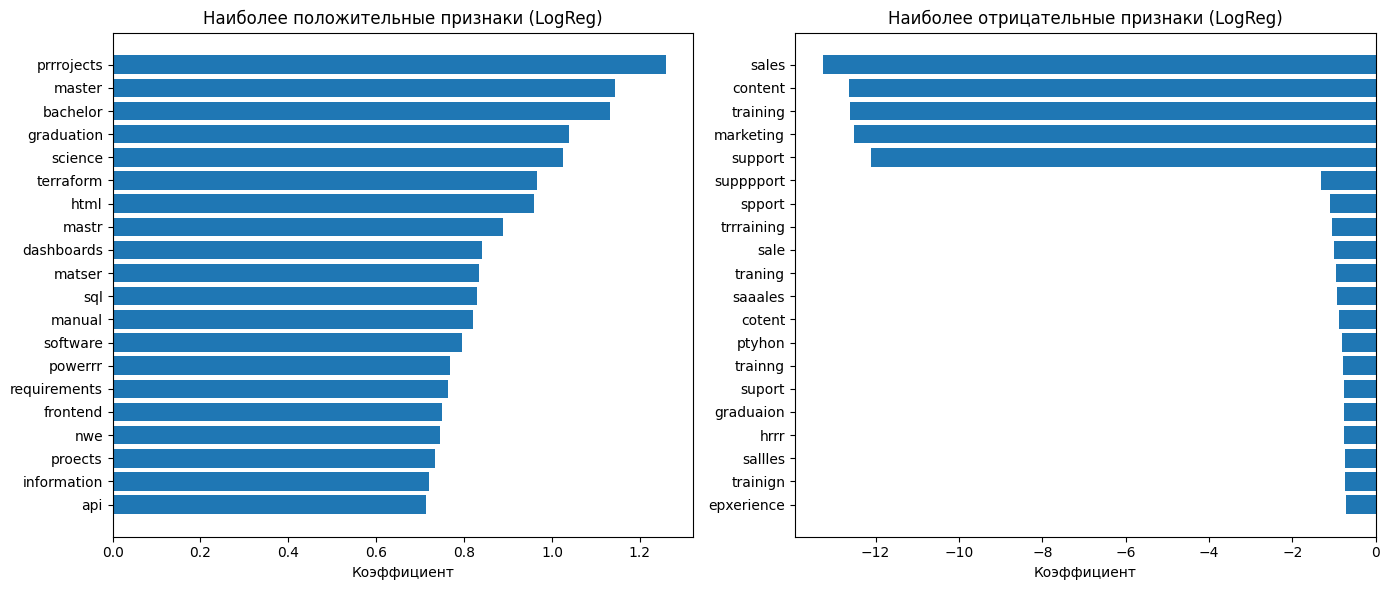

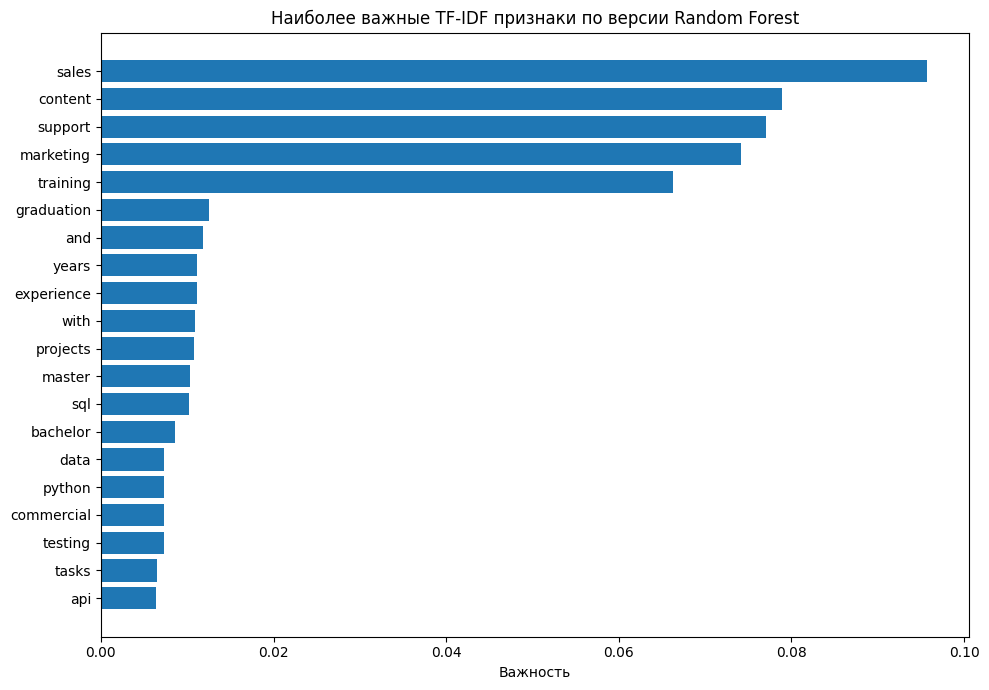

In [16]:
# Логистическая регрессия: наиболее положительные/отрицательные признаки
feature_names = np.array(tfidf.get_feature_names_out())
coefs = log_reg.coef_[0]

top_n = 20
top_pos = np.argsort(coefs)[-top_n:][::-1]
top_neg = np.argsort(coefs)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(feature_names[top_pos][::-1], coefs[top_pos][::-1])
axes[0].set_title("Наиболее положительные признаки (LogReg)")
axes[0].set_xlabel("Коэффициент")

axes[1].barh(feature_names[top_neg][::-1], coefs[top_neg][::-1])
axes[1].set_title("Наиболее отрицательные признаки (LogReg)")
axes[1].set_xlabel("Коэффициент")

plt.tight_layout()
plt.show()

# Важность признаков в Random Forest
importances = rf.feature_importances_
idx = np.argsort(importances)[-top_n:][::-1]

plt.figure(figsize=(10, 7))
plt.barh(feature_names[idx][::-1], importances[idx][::-1])
plt.title("Наиболее важные TF‑IDF признаки по версии Random Forest")
plt.xlabel("Важность")
plt.tight_layout()
plt.show()

In [17]:
results.to_csv("metrics_results.csv", index=False)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": log_reg.coef_[0]
}).sort_values("coef", ascending=False)
coef_df.to_csv("logreg_feature_coefficients.csv", index=False)

print("Сохранённые файлы:")
print("- metrics_results.csv")
print("- logreg_feature_coefficients.csv")

Сохранённые файлы:
- metrics_results.csv
- logreg_feature_coefficients.csv


## Этап 1: Финализация baseline

Baseline-пайплайн готов: TF-IDF (1–2-граммы) + LogisticRegression / RandomForest / CatBoost.  
Результаты сохранены выше (`metrics_results.csv`).  
Далее — Этапы 2–6: NER, скрытые признаки, гибридный классификатор и финальное сравнение.


## Этапы 2–3: Правилоориентированный NER

Извлекаем именованные сущности из текстов резюме без ручной разметки:

| Сущность | Источник |
|---|---|
| Навыки | столбец `skills`, поиск ключевых слов в тексте |
| Уровень должности | `last_position` → seniority score |
| Образование | `education` → степень + год |
| Опыт | `total_experience` |
| Скрытые признаки | плотность опечаток, soft skills, глаголы действия |


In [ ]:
import sys, os
sys.path.insert(0, os.getcwd())

from ner_module import (
    extract_ner_features, NER_FEATURE_NAMES, NER_FEATURE_NAMES_RU,
    SENIORITY_LABELS, EDU_LABELS, detect_typo_density, get_seniority, get_edu_level,
)

# Извлекаем NER-признаки для всего датасета
ner_rows = []
for _, row in df.iterrows():
    ner_rows.append(extract_ner_features(row.to_dict()))

df_ner = pd.DataFrame(ner_rows, index=df.index)
df_ner.columns = NER_FEATURE_NAMES

print("NER-матрица:", df_ner.shape)
display(df_ner.head(5))


In [ ]:
# Визуализация NER-признаков по классам
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feat in enumerate(NER_FEATURE_NAMES):
    ax = axes[i]
    data0 = df_ner.loc[df["target"] == 0, feat]
    data1 = df_ner.loc[df["target"] == 1, feat]
    ax.boxplot([data0, data1], labels=["Не пригласить", "Пригласить"], showfliers=False)
    ax.set_title(NER_FEATURE_NAMES_RU[feat], fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle("NER-признаки по классам", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## Этап 4: Анализ скрытых признаков

Три наиболее интерпретируемых скрытых признака:

1. **typo_density** — доля слов с 3+ повторяющимися символами. Косвенно отражает небрежность кандидата.
2. **soft_skills_count** — количество упоминаний гибких навыков (командная работа, коммуникации…).
3. **seniority** — числовой уровень должности из текста `last_position`.


In [ ]:
from collections import Counter

# Примеры кандидатов с высокой плотностью опечаток
import re
def find_typos(text):
    return [w for w in str(text).split() if re.search(r"(.){2,}", w.lower())]

df["typo_count"] = df["full_text"].apply(lambda t: len(find_typos(t)))
df["typo_density"] = df_ner["typo_density"]

print("Средняя плотность опечаток по классам:")
print(df.groupby("target")["typo_density"].mean().round(4))

# Примеры слов-опечаток
all_typos = []
for text in df["full_text"]:
    all_typos.extend(find_typos(str(text)))
print("\nТоп-10 слов с опечатками:", Counter(all_typos).most_common(10))


In [ ]:
# Корреляция NER-признаков с целевой переменной
corr = df_ner.assign(target=df["target"]).corr()["target"].drop("target").sort_values()

plt.figure(figsize=(8, 5))
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in corr]
plt.barh(corr.index.map(lambda x: NER_FEATURE_NAMES_RU.get(x, x)), corr.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Корреляция NER-признаков с целевой переменной")
plt.xlabel("Pearson r")
plt.tight_layout()
plt.show()


## Этап 5: Гибридный классификатор

Объединяем TF-IDF (5000 признаков) + 9 NER-признаков.  
Обучаем LogReg, RandomForest и CatBoost на гибридном векторе.


In [ ]:
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler

# Масштабируем NER-признаки
ner_scaler = StandardScaler()
ner_train_vals = df_ner.loc[X_train.index].values.astype(float)
ner_test_vals  = df_ner.loc[X_test.index].values.astype(float)

ner_train_s = ner_scaler.fit_transform(ner_train_vals)
ner_test_s  = ner_scaler.transform(ner_test_vals)

# Гибридный вектор
X_train_hybrid = hstack([X_train_tfidf, csr_matrix(ner_train_s)])
X_test_hybrid  = hstack([X_test_tfidf,  csr_matrix(ner_test_s)])

print("Гибридная матрица train:", X_train_hybrid.shape)
print("Гибридная матрица test: ", X_test_hybrid.shape)


In [ ]:
# Логистическая регрессия (гибридная)
log_reg_h = LogisticRegression(C=1.0, penalty="l2", solver="lbfgs",
                                max_iter=1000, random_state=RANDOM_STATE)
log_reg_h.fit(X_train_hybrid, y_train)

# Random Forest (гибридный)
rf_h = RandomForestClassifier(n_estimators=150, max_depth=20,
                               random_state=RANDOM_STATE, n_jobs=-1)
rf_h.fit(X_train_hybrid, y_train)

# CatBoost через SVD (гибридный)
n_comp_h = min(100, X_train_hybrid.shape[1] - 1)
svd_h = TruncatedSVD(n_components=n_comp_h, random_state=RANDOM_STATE)
X_train_svd_h = svd_h.fit_transform(X_train_hybrid)
X_test_svd_h  = svd_h.transform(X_test_hybrid)

cat_h = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    loss_function="Logloss", verbose=100,
    random_state=RANDOM_STATE, allow_writing_files=False,
)
cat_h.fit(X_train_svd_h, y_train,
          eval_set=(X_test_svd_h, y_test), use_best_model=True)

print("\nГибридные модели обучены.")


## Этап 6: Оценка и сравнение Baseline vs Гибридный

In [ ]:
# Предсказания гибридных моделей
log_pred_h  = log_reg_h.predict(X_test_hybrid)
log_proba_h = log_reg_h.predict_proba(X_test_hybrid)[:, 1]

rf_pred_h  = rf_h.predict(X_test_hybrid)
rf_proba_h = rf_h.predict_proba(X_test_hybrid)[:, 1]

cat_pred_h  = cat_h.predict(X_test_svd_h).astype(int)
cat_proba_h = cat_h.predict_proba(X_test_svd_h)[:, 1]

results_hybrid = pd.DataFrame([
    evaluate_model("Hybrid LogReg",  y_test, log_pred_h,  log_proba_h),
    evaluate_model("Hybrid RF",      y_test, rf_pred_h,   rf_proba_h),
    evaluate_model("Hybrid CatBoost",y_test, cat_pred_h,  cat_proba_h),
])

results_all = pd.concat([results, results_hybrid], ignore_index=True) \
                .sort_values("roc_auc", ascending=False)

display(results_all.style.highlight_max(
    subset=["accuracy","precision","recall","f1","roc_auc"],
    color="#d4edda"
).format(precision=4))


In [ ]:
# ROC-кривые: Baseline vs Гибридный
plt.figure(figsize=(9, 7))
model_probas = {
    "Baseline LR":       log_proba,
    "Baseline RF":       rf_proba,
    "Baseline CatBoost": cat_proba,
    "Hybrid LR":         log_proba_h,
    "Hybrid RF":         rf_proba_h,
    "Hybrid CatBoost":   cat_proba_h,
}
linestyles = {"Baseline": "--", "Hybrid": "-"}
for name, proba in model_probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    ls = "--" if "Baseline" in name else "-"
    plt.plot(fpr, tpr, linestyle=ls, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0, 1], [0, 1], "k:", label="Случайная модель")
plt.title("ROC-кривые: Baseline vs Гибридный", fontsize=14)
plt.xlabel("Доля ложноположительных (FPR)")
plt.ylabel("Доля истинноположительных (TPR)")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Матрицы ошибок гибридных моделей
plot_cm(y_test, log_pred_h,  "Гибридная LogReg")
plot_cm(y_test, rf_pred_h,   "Гибридная RF")
plot_cm(y_test, cat_pred_h,  "Гибридная CatBoost")


In [ ]:
# Важность признаков гибридной LogReg
from ner_module import NER_FEATURE_NAMES, NER_FEATURE_NAMES_RU

feature_names_all = np.array(
    list(tfidf.get_feature_names_out()) + NER_FEATURE_NAMES
)
coefs_h = log_reg_h.coef_[0]
top_n = 20

# Топ-N по абсолютному значению
top_idx = np.argsort(np.abs(coefs_h))[-top_n:][::-1]
top_features = feature_names_all[top_idx]
top_coefs    = coefs_h[top_idx]

# Переводим NER-признаки на русский
top_features_ru = [NER_FEATURE_NAMES_RU.get(f, f) for f in top_features]
colors = ["#2ecc71" if c > 0 else "#e74c3c" for c in top_coefs]

plt.figure(figsize=(10, 7))
plt.barh(top_features_ru[::-1], top_coefs[::-1], color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Топ-20 признаков гибридной LogReg (по |коэффициенту|)", fontsize=13)
plt.xlabel("Коэффициент")
plt.tight_layout()
plt.show()


## Объяснение решения для HR

Пример: берём первый тестовый кандидат и показываем, почему модель рекомендует / не рекомендует его.


In [ ]:
def explain_decision_ru(idx, df, tfidf, log_reg_h, ner_scaler, X_test_tfidf, ner_test_vals):
    """Объясняет решение для кандидата с индексом idx."""
    from ner_module import NER_FEATURE_NAMES, NER_FEATURE_NAMES_RU

    row_pos = list(X_test.index).index(idx)
    tfidf_vec = X_test_tfidf[row_pos]
    ner_vec   = ner_scaler.transform(ner_test_vals[row_pos:row_pos+1])[0]

    feature_names = list(tfidf.get_feature_names_out()) + NER_FEATURE_NAMES
    coefs = log_reg_h.coef_[0]

    scores = []
    # TF-IDF
    for i in tfidf_vec.nonzero()[1]:
        scores.append((feature_names[i], float(coefs[i] * tfidf_vec[0, i])))
    # NER
    n_tfidf = len(tfidf.vocabulary_)
    for j, name in enumerate(NER_FEATURE_NAMES):
        score = float(coefs[n_tfidf + j] * ner_vec[j])
        scores.append((NER_FEATURE_NAMES_RU.get(name, name), score))

    scores.sort(key=lambda x: abs(x[1]), reverse=True)
    pos = [(f, s) for f, s in scores if s > 0][:5]
    neg = [(f, s) for f, s in scores if s < 0][:5]

    proba = log_reg_h.predict_proba(
        hstack([tfidf_vec, csr_matrix(ner_vec.reshape(1, -1))])
    )[0, 1]
    verdict = "✅ ПРИГЛАСИТЬ" if proba >= 0.5 else "❌ НЕ ПРИГЛАСИТЬ"

    row = df.loc[idx]
    print(f"Кандидат: {row.get('position','?')} | Опыт: {row.get('total_experience','?')} лет")
    print(f"Должность: {row.get('last_position','?')}")
    print(f"\nОценка: {proba:.2%}  →  {verdict}")
    print("\nФакторы «за»:")
    for f, s in pos:
        print(f"  + {f}: {s:+.4f}")
    print("\nФакторы «против»:")
    for f, s in neg:
        print(f"  - {f}: {s:+.4f}")

# Показываем первые 3 тестовых кандидата
for sample_idx in list(X_test.index)[:3]:
    print("=" * 60)
    explain_decision_ru(sample_idx, df, tfidf, log_reg_h, ner_scaler,
                        X_test_tfidf, ner_test_vals)
print("=" * 60)


## Сохранение моделей

Все артефакты сохраняются в папку `models/` для использования в Streamlit-приложении (`app.py`).


In [ ]:
import os, joblib

os.makedirs("models", exist_ok=True)

artifacts = {
    "tfidf":        tfidf,
    "baseline_lr":  log_reg,
    "baseline_rf":  rf,
    "baseline_svd": svd,
    "baseline_cat": cat,
    "hybrid_lr":    log_reg_h,
    "hybrid_rf":    rf_h,
    "hybrid_svd":   svd_h,
    "hybrid_cat":   cat_h,
    "ner_scaler":   ner_scaler,
}

for name, obj in artifacts.items():
    path = f"models/{name}.joblib"
    joblib.dump(obj, path)
    print(f"  Сохранено: {path}")

# Сводная таблица метрик
results_all.to_csv("metrics_comparison.csv", index=False)
print("\nmetrics_comparison.csv сохранён.")
print("\n✅ Все модели сохранены. Запустите приложение командой:")
print("   streamlit run app.py")
